## 0. Setup


In [3]:
try:
    import mediapipe as mp
    print('MediaPipe version:', mp.__version__)
except ImportError:
    !pip install -q mediapipe
    import mediapipe as mp
    print('Installed MediaPipe', mp.__version__)

import os, pickle
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

DATASET_ROOT = Path('/kaggle/input/datasets/grassknoted/asl-alphabet/asl_alphabet_train/asl_alphabet_train')
OUT  = Path('/kaggle/working')
DATA_OUT = OUT / 'data'
LOG_OUT  = OUT / 'logs'
DATA_OUT.mkdir(parents=True, exist_ok=True)
LOG_OUT.mkdir(parents=True, exist_ok=True)

print('Dataset root exists:', DATASET_ROOT.exists())


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 85.2 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 7.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


2026-05-01 07:09:13.152535: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777619353.418642      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777619353.490772      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777619354.125774      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777619354.125832      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777619354.125836      57 computation_placer.cc:177] computation placer alr

Installed MediaPipe 0.10.35
Dataset root exists: True


## 1. Inspect the class folders


In [4]:
class_dirs = sorted([p for p in DATASET_ROOT.iterdir() if p.is_dir()])
print(f'Found {len(class_dirs)} class folders:')
for p in class_dirs:
    n_imgs = len(list(p.glob('*.jpg')))
    print(f'  {p.name:10s} — {n_imgs} images')

Found 29 class folders:
  A          — 3000 images
  B          — 3000 images
  C          — 3000 images
  D          — 3000 images
  E          — 3000 images
  F          — 3000 images
  G          — 3000 images
  H          — 3000 images
  I          — 3000 images
  J          — 3000 images
  K          — 3000 images
  L          — 3000 images
  M          — 3000 images
  N          — 3000 images
  O          — 3000 images
  P          — 3000 images
  Q          — 3000 images
  R          — 3000 images
  S          — 3000 images
  T          — 3000 images
  U          — 3000 images
  V          — 3000 images
  W          — 3000 images
  X          — 3000 images
  Y          — 3000 images
  Z          — 3000 images
  del        — 3000 images
  nothing    — 3000 images
  space      — 3000 images


## 2. Set up MediaPipe Hands


In [ ]:
import urllib.request
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision

MODEL_PATH = OUT / 'hand_landmarker.task'
if not MODEL_PATH.exists():
    urllib.request.urlretrieve(
        'https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/latest/hand_landmarker.task',
        MODEL_PATH,
    )
print('Model ready:', MODEL_PATH)

options = vision.HandLandmarkerOptions(
    base_options=mp_python.BaseOptions(model_asset_path=str(MODEL_PATH)),
    num_hands=1,
    running_mode=vision.RunningMode.IMAGE,
    min_hand_detection_confidence=0.5,
)
detector = vision.HandLandmarker.create_from_options(options)


Model ready: /kaggle/working/hand_landmarker.task


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1777619466.695837     149 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777619466.725207     149 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## 3. Helpers: image → normalized landmark vector


In [7]:
def normalize_landmarks(landmark_list):
    """List of NormalizedLandmark → (63,) wrist-relative, unit-scaled vector."""
    coords = np.array([[lm.x, lm.y, lm.z] for lm in landmark_list], dtype=np.float32)
    wrist = coords[0].copy()
    coords -= wrist
    max_d = np.linalg.norm(coords, axis=1).max()
    if max_d > 0:
        coords /= max_d
    return coords.flatten()

def image_to_features(img_path: Path):
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    result = detector.detect(mp_image)
    if not result.hand_landmarks:
        return None
    return normalize_landmarks(result.hand_landmarks[0])


## 4. Process the dataset


In [ ]:
IMAGES_PER_CLASS = 500
rng = np.random.default_rng(42)

LABEL_MAP = {'space': 'SPACE', 'del': 'DELETE', 'nothing': 'NOTHING'}

rows = []
detection_stats = []

for class_dir in tqdm(class_dirs, desc='classes'):
    raw_name = class_dir.name
    label = LABEL_MAP.get(raw_name, raw_name.upper())

    img_paths = sorted(class_dir.glob('*.jpg'))
    if len(img_paths) > IMAGES_PER_CLASS:
        idxs = rng.choice(len(img_paths), size=IMAGES_PER_CLASS, replace=False)
        img_paths = [img_paths[i] for i in idxs]

    detected = 0
    for p in img_paths:
        feats = image_to_features(p)
        if feats is None:
            if label == 'NOTHING':
                rows.append({'features': np.zeros(63, dtype=np.float32),
                             'label': 'NOTHING', 'image': p.name})
            continue
        detected += 1
        rows.append({'features': feats, 'label': label, 'image': p.name})

    detection_stats.append({
        'label': label,
        'images_seen': len(img_paths),
        'hand_detected': detected,
        'detection_rate': detected / len(img_paths) if img_paths else 0.0,
    })

alphabet_df = pd.DataFrame(rows)
stats_df = pd.DataFrame(detection_stats).sort_values('detection_rate')

print(f'Total samples kept: {len(alphabet_df)}')
print(f'Unique labels    : {alphabet_df["label"].nunique()}')
print('\nDetection rate by class (lowest 10):')
print(stats_df.head(10).to_string(index=False))

classes:   0%|          | 0/29 [00:00<?, ?it/s]

Total samples kept: 11089
Unique labels    : 29

Detection rate by class (lowest 10):
  label  images_seen  hand_detected  detection_rate
NOTHING          500              0           0.000
      N          500            205           0.410
      M          500            271           0.542
  SPACE          500            272           0.544
 DELETE          500            307           0.614
      P          500            329           0.658
      C          500            341           0.682
      A          500            348           0.696
      Q          500            355           0.710
      X          500            363           0.726


## 5. Save the processed data


In [10]:
alphabet_out = DATA_OUT / 'alphabet_landmarks.pkl'
alphabet_df.to_pickle(alphabet_out)
stats_df.to_csv(LOG_OUT / 'alphabet_detection_rate.csv', index=False)

print('Saved:', alphabet_out, '— size MB:', alphabet_out.stat().st_size / 1e6)
print('Saved:', LOG_OUT / 'alphabet_detection_rate.csv')

Saved: /kaggle/working/data/alphabet_landmarks.pkl — size MB: 3.261696
Saved: /kaggle/working/logs/alphabet_detection_rate.csv


## 6. Class distribution after detection failures


label
A          348
B          364
C          341
D          409
DELETE     307
E          398
F          476
G          400
H          395
I          394
J          430
K          455
L          425
M          271
N          205
NOTHING    500
O          382
P          329
Q          355
R          417
S          428
SPACE      272
T          387
U          420
V          414
W          400
X          363
Y          423
Z          381
Name: count, dtype: int64

Max/min ratio: 2.44x


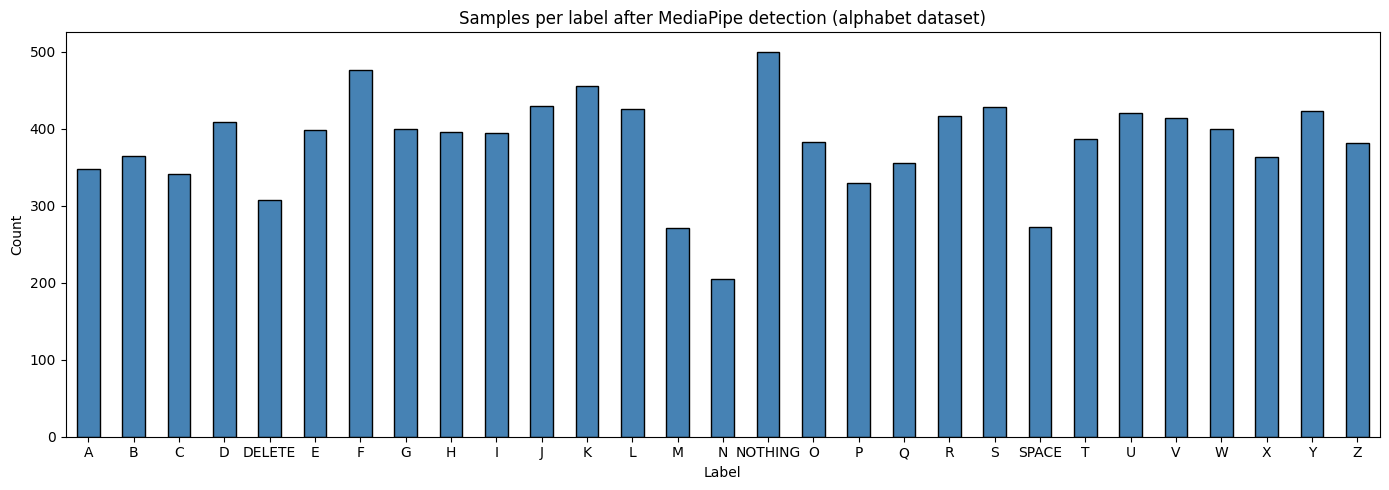

In [11]:
counts = alphabet_df['label'].value_counts().sort_index()
print(counts)
print(f'\nMax/min ratio: {counts.max() / counts.min():.2f}x')

fig, ax = plt.subplots(figsize=(14, 5))
counts.plot(kind='bar', color='steelblue', edgecolor='black', ax=ax)
ax.set_title('Samples per label after MediaPipe detection (alphabet dataset)')
ax.set_xlabel('Label')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(LOG_OUT / 'alphabet_class_distribution.png', dpi=150)
plt.show()

## 7. Stratified train/val/test split


In [12]:
from sklearn.model_selection import train_test_split

idx = np.arange(len(alphabet_df))
y   = alphabet_df['label'].values

train_idx, temp_idx = train_test_split(idx, test_size=0.2, random_state=42, stratify=y)
val_idx, test_idx   = train_test_split(temp_idx, test_size=0.5, random_state=42, stratify=y[temp_idx])

splits = {'train_idx': train_idx.tolist(), 'val_idx': val_idx.tolist(), 'test_idx': test_idx.tolist()}
with open(DATA_OUT / 'alphabet_splits.pkl', 'wb') as f:
    pickle.dump(splits, f)

print(f'train: {len(train_idx)}, val: {len(val_idx)}, test: {len(test_idx)}')

train: 8871, val: 1109, test: 1109


## 8. Sanity check — quick inter-class variance


In [13]:
X = np.stack(alphabet_df['features'].values)
feature_names = [f'{ax}_lm{i}' for i in range(21) for ax in ('x', 'y', 'z')]

class_means = {}
for lab in sorted(alphabet_df['label'].unique()):
    Xc = np.stack(alphabet_df.loc[alphabet_df['label'] == lab, 'features'].values)
    class_means[lab] = Xc.mean(axis=0)

means_df = pd.DataFrame(class_means, index=feature_names).T
inter_class_var = means_df.var(axis=0).sort_values(ascending=False)

print('Top 10 most discriminative features (inter-class variance):')
print(inter_class_var.head(10))
print(f'\nFingerspelling top variance was 0.007 — compare to {inter_class_var.iloc[0]:.4f} here.')

Top 10 most discriminative features (inter-class variance):
x_lm8     0.194710
y_lm12    0.180354
x_lm7     0.159951
y_lm8     0.153096
x_lm4     0.149634
x_lm12    0.132437
y_lm11    0.125316
x_lm6     0.121728
y_lm16    0.117832
x_lm11    0.116795
dtype: float32

Fingerspelling top variance was 0.007 — compare to 0.1947 here.


## 9. Cleanup


In [14]:
detector.close()
print('Done.')

Done.
